In [1]:
import os
import random
from sklearn.model_selection import train_test_split

In [2]:
cloud_dir = "../data/raw/RICE1/cloud"
label_dir = "../data/raw/RICE1/label"

cloud_images = sorted(os.listdir(cloud_dir))
label_images = sorted(os.listdir(label_dir))

print("Total Images:", len(cloud_images))

Total Images: 500


In [3]:
pairs = list(zip(cloud_images, label_images))

train_pairs, val_pairs = train_test_split(
    pairs,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Training Images :", len(train_pairs))
print("Validation Images:", len(val_pairs))

Training Images : 400
Validation Images: 100


In [4]:
print("\nFirst Training Pair")
print(train_pairs[0])

print("\nFirst Validation Pair")
print(val_pairs[0])


First Training Pair
('322.png', '322.png')

First Validation Pair
('423.png', '423.png')


In [6]:
import os

print(os.listdir("../src/dataset"))

['data_loader.py', '__init__.py', '__pycache__']


In [9]:
import sys
import os

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

from src.dataset.data_loader import RiceDataset
from torch.utils.data import DataLoader

ImportError: cannot import name 'RiceDataset' from 'src.dataset.data_loader' (c:\Users\LENOVO\OneDrive\Desktop\GeoRestore AI\GeoRestore-AI\src\dataset\data_loader.py)

In [10]:
import importlib
import src.dataset.data_loader as dl

print(dl.__file__)

importlib.reload(dl)

print(dir(dl))

c:\Users\LENOVO\OneDrive\Desktop\GeoRestore AI\GeoRestore-AI\src\dataset\data_loader.py
['Dataset', 'RiceDataset', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'cv2', 'os', 'torch']


In [1]:
import sys
import os

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

from src.dataset.data_loader import RiceDataset
from torch.utils.data import DataLoader

print("Import Successful!")

Import Successful!


In [2]:
train_dataset = RiceDataset("../data/raw/RICE1")

print("Total Images:", len(train_dataset))

Total Images: 500


In [3]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

print("Total Batches:", len(train_loader))

Total Batches: 63


In [4]:
images, labels = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

print("Images dtype :", images.dtype)
print("Labels dtype :", labels.dtype)

Images Shape : torch.Size([8, 3, 512, 512])
Labels Shape : torch.Size([8, 3, 512, 512])
Images dtype : torch.float32
Labels dtype : torch.float32


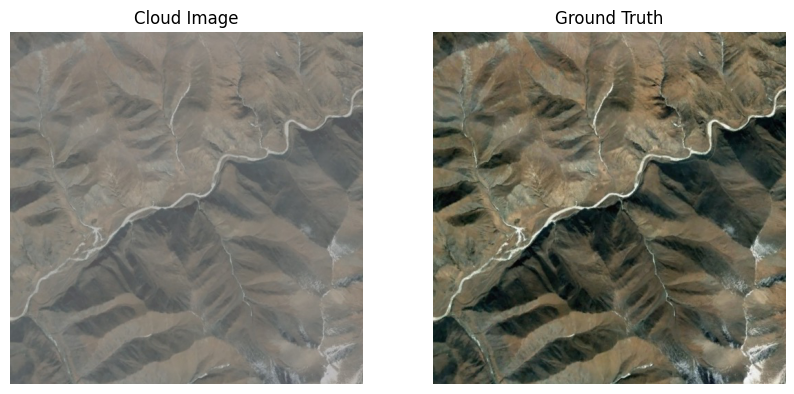

In [5]:
import matplotlib.pyplot as plt

cloud = images[0].permute(1, 2, 0).numpy()
label = labels[0].permute(1, 2, 0).numpy()

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cloud)
plt.title("Cloud Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(label)
plt.title("Ground Truth")
plt.axis("off")

plt.show()